# 🐍 Python Level 2 - Intermediate course
## Class 3 — Data Visualisation

**Python instructor - Catarina Santos**

---

<div style="display:inline-flex; align-items:center; gap:28px; background:#FFFFFF; color:#1D1D1B; padding:10px 14px; border-radius:8px; margin-bottom:8px;">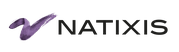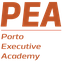</div>

---

---

### 📋 What we'll cover today

| # | Topic |
|---|-------|
| 1 | Why visualise? And which chart for which question |
| 2 | matplotlib — your first chart |
| 3 | Labels, legend, grid, and more than one line |
| 4 | The four chart types you actually need |
| 5 | Several charts in one figure |
| 6 | Charts straight from a DataFrame |
| 7 | seaborn — nicer charts, less code |
| 8 | 🔗 Putting it all together |

### 🎯 Learning outcomes

By the end of this class you will be able to:

- Choose the right chart for the question you are answering
- Build and label a chart with matplotlib
- Chart a `groupby` result straight out of pandas
- Save a finished figure to a file you can put in a report

---

---
## 1. Why visualise? And which chart for which question

A table gives exact values. A chart gives **shape** which is bigger, what is rising, what is
unusual. You need both, and for different jobs.

### Which chart for which question

The chart follows from the question, not from taste:

```
            What are you showing?
                     │
    ┌───────────┬────┴────┬────────────┐
    ▼           ▼         ▼            ▼
 change      compare   one number   two numbers
 over time    groups   spread out    compared
    │           │         │            │
    ▼           ▼         ▼            ▼
  line         bar     histogram     scatter
```

| Question | Chart |
|----------|-------|
| How did spend move month by month? | **line** |
| Which department spent most? | **bar** |
| Are most invoices small or large? | **histogram** |
| Do bigger budgets mean bigger overspends? | **scatter** |

### What makes a chart bad

| ❌ Bad | ✅ Good |
|--------|---------|
| No title — the reader has to guess | A title saying what they are looking at |
| Unlabelled axes | Both axes labelled, with units |
| Twelve colours for twelve bars | One colour, unless colour *means* something |
| A pie chart with nine slices | A bar chart, sorted |
| Squeezed so labels overlap | `figsize` big enough, labels rotated if needed |

> 💡 The test: cover the chart and say the sentence it is supposed to prove. If you cannot, the
> chart has no job.

---
## 2. matplotlib — your first chart

**matplotlib** is the library everything else is built on. The convention, as universal as
`pd` for pandas:

```
import matplotlib.pyplot as plt
```

Three steps, always the same: give it data, decorate it, then show it.

| Step | Call |
|------|------|
| Draw | `plt.plot(x_values, y_values)` |
| Show | `plt.show()` |

`plt.plot()` takes two lists where the x values and the y values and joins the points with a
line. Colab draws the chart underneath the cell.


In [ ]:
import matplotlib.pyplot as plt

months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun"]
spend = [530565, 429137, 428804, 564693, 533067, 499512]

In [ ]:
plt.plot(months, spend)
plt.show()

You can change how the line looks with keyword arguments, exactly like the ones you learned in
Class 1 of this level:

| Argument | Does |
|----------|------|
| `color="green"` | the line colour |
| `marker="o"` | put a dot at each data point |
| `linestyle="--"` | dashed instead of solid |
| `linewidth=2` | thicker |

> ⚠️ `plt.show()` also **clears** the figure. Everything you want on one chart must be drawn
> before you call it.

In [ ]:
# The same data, with the line styled
plt.plot(months, spend, color="purple", marker="o", linestyle="--", linewidth=2)
plt.show()

---
## 3. Labels, legend, grid, and more than one line

A chart without labels is a puzzle. Four calls fix that, and they all go **before**
`plt.show()`:

| Call | Adds |
|------|------|
| `plt.title("...")` | the title |
| `plt.xlabel("...")` / `plt.ylabel("...")` | axis labels |
| `plt.grid(True)` | gridlines, which make values readable |
| `plt.legend()` | the key — but only if your lines have `label=` |
| `plt.figure(figsize=(9, 4))` | a bigger canvas, **before** you draw |

### More than one line

Call `plt.plot()` twice before `plt.show()` and both lines land on the same chart. Give each a
`label=` and then call `plt.legend()` so the reader knows which is which.

In [ ]:
budget = [560000, 480000, 470000, 545000, 520000, 505000]

plt.figure(figsize=(9, 4))                     # bigger canvas, set up first
plt.plot(months, spend, marker="o", label="Actual")
plt.plot(months, budget, marker="s", linestyle="--", label="Budget")

plt.title("Spend vs budget by month")
plt.xlabel("Month")
plt.ylabel("EUR")

plt.grid(True)
plt.legend()

plt.show()                                 # needs the label= above

---
## 4. The four chart types you actually need

Same three calls every time where only the drawing function changes.

| Function | Chart | Use it for |
|----------|-------|-----------|
| `plt.plot(x, y)` | line | change over time |
| `plt.bar(x, heights)` | bar | comparing groups |
| `plt.hist(values, bins=10)` | histogram | how one number is spread out |
| `plt.scatter(x, y)` | scatter | two numbers against each other |

A **histogram** is the one people find unfamiliar: it takes a single list of numbers, sorts them
into `bins`, and shows how many fell in each. It answers *"are most of these small or large?"*

### Barplot
*Comparing groups*

In [ ]:
departments = ["finance", "hr", "it", "marketing", "operations"]
totals = [557059, 510648, 634992, 635418, 647662]

In [ ]:
plt.bar(departments, totals, color="teal")
plt.title("Total spend by department")
plt.ylabel("EUR")
plt.show()

`plt.barh()` is the same as `plt.bar()` but with horizontal bars which are much better when the labels are long
names.

### Histogram
*How one number is spread out*

In [ ]:
# 24 individual spend lines, smallest to largest
line_amounts = [2100, 3400, 4200, 5100, 5800, 6700, 7300, 8100, 8900, 9400,
                10500, 11200, 12800, 14300, 15100, 16900, 18700, 20100,
                22400, 25900, 28300, 31200, 35800, 41500]

In [ ]:
plt.hist(line_amounts, bins=6, color="teal")
plt.title("How individual amounts are spread")
plt.xlabel("EUR")
plt.ylabel("How many lines")
plt.show()

### Scatter Plot
*Two numbers against each other*

In [ ]:
plt.scatter(budget, spend, color="teal")
plt.title("Budget against actual, by month")
plt.xlabel("Budget (EUR)")
plt.ylabel("Actual (EUR)")
plt.show()

---
## 5. Several charts in one figure

`plt.subplot(rows, columns, position)` splits the canvas into a grid and picks which cell to
draw in next. Positions are numbered **left to right, then top to bottom**, starting at 1.

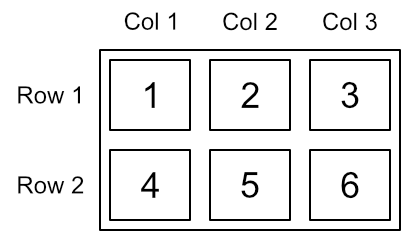

Two calls make the result presentable:

- `plt.figure(figsize=(11, 7))` first, or the cells will be cramped
- `plt.tight_layout()` last, which stops titles and labels overlapping

In [ ]:
plt.figure(figsize=(10, 6))

plt.subplot(2, 2, 1)
plt.plot(months, spend, marker="o")
plt.title("Spend by month")

plt.subplot(2, 2, 2)
plt.bar(departments, totals)
plt.title("By department")
plt.xticks(rotation=45)

plt.subplot(2, 2, 3)
plt.hist(line_amounts, bins=6)
plt.title("Amounts")

plt.subplot(2, 2, 4)
plt.scatter(budget, spend)
plt.title("Budget vs actual")

plt.tight_layout()                 # keeps the four from overlapping
plt.show()

---
## 6. Charts straight from a DataFrame

Everything so far used plain lists. In practice your numbers come out of pandas and a
`groupby` result plots directly.

Two ways, and both are worth knowing:

| Way | Write | When |
|-----|-------|------|
| pandas does it | `by_dept.plot(kind="bar")` | quick look while you work |
| matplotlib does it | `plt.bar(by_dept.index, by_dept.values)` | when you want full control |

`df.plot(kind=...)` accepts `"line"`, `"bar"`, `"barh"`, `"hist"` and `"scatter"`. It is the
fastest chart you can make.

> 💡 A grouped result has an **index** (the group names) and **values** (the numbers).
> `.index` and `.values` are what you hand to matplotlib when you want to decorate it yourself.

In [ ]:
import pandas as pd

# Put expenses.csv in your Google Colab folder space first, then run this cell and allow access.
CSV_PATH = "expenses.csv"
expenses = pd.read_csv(CSV_PATH)
print(expenses.shape)

In [ ]:
# Clean the file
expenses = expenses.drop_duplicates()

In [ ]:
expenses["department"] = expenses["department"].str.lower()

In [ ]:
expenses = expenses.drop(columns=["notes"]).dropna(subset=["actual"])

In [ ]:
print(expenses.shape)

In [ ]:
# A groupby result, straight to a chart
by_department = expenses.groupby("department")["actual"].sum().round(2)

In [ ]:
print(by_department)

In [ ]:
by_department.plot(kind="bar", figsize=(8, 4), color="teal")
plt.title("Total actual spend by department")
plt.ylabel("EUR")
plt.tight_layout()
plt.show()

In [ ]:
# The same result, drawn by matplotlib so we control every part of it
by_month = expenses.groupby("month")["actual"].sum().round(2)

In [ ]:
plt.figure(figsize=(9, 4))
plt.plot(by_month.index, by_month.values, marker="o", color="purple")
plt.title("Actual spend by month")
plt.xlabel("Month")
plt.ylabel("EUR")
plt.grid(True)
plt.show()

---
## 7. seaborn — nicer charts, less code

**seaborn** sits on top of matplotlib. Same figures underneath, but better-looking defaults and
the real gain is that can read a **DataFrame directly**, so you name columns instead of
extracting values.

```
import seaborn as sns
```

| seaborn call | Draws |
|--------------|-------|
| `sns.countplot(data=df, x="category")` | how many rows per category — it counts for you |
| `sns.barplot(data=df, x="department", y="actual")` | the **average** per group, with error bars |
| `sns.boxplot(data=df, x="department", y="actual")` | the spread per group |
| `sns.histplot(data=df, x="actual", bins=10)` | a nicer histogram |
| `sns.set_style("whitegrid")` | applies a tidy style to everything after it |

A **boxplot** is worth a moment: the box covers the middle half of the values, the line inside
is the middle value, and the whiskers reach the rest. It answers *"is this group consistent, or
all over the place?"* which no bar chart can tell you.

> ⚠️ `sns.barplot` shows the **mean** per group, not the total. If you want totals, `groupby`
> them first and use a bar chart.

| Tool | Use when |
|------|----------|
| `df.plot()` | you want a chart in one line while exploring |
| `seaborn` | you have a DataFrame and want it to look good with little effort |
| `matplotlib` | you want to control every detail, or combine several charts |

In [ ]:
import seaborn as sns

sns.set_style("whitegrid")         # applies to everything drawn after this

plt.figure(figsize=(9, 4))
sns.countplot(data=expenses, x="category")

plt.title("How many spend lines per category")
plt.show()

In [ ]:
plt.figure(figsize=(9, 4))
sns.boxplot(data=expenses, x="department", y="actual")

plt.title("Spread of individual amounts by department")
plt.ylabel("EUR")
plt.show()

---
## 8. 🔗 Putting it all together with a monthly expenses dashboard

One figure, four charts, saved to a file you could drop into a report.

### The situation

The finance team wants a single page each month. Not a table but a page they can
glance at and answer four questions:

- Is spend rising or falling?  →  **spend by month**
- Which departments are the heavy ones?  →  **spend by department**
- Are the individual amounts normal, or are there outliers?  →  **spread of amounts**
- Did budgets predict actuals?  →  **budget vs actual**

### The pipeline

```
expenses          (cleaned DataFrame)
    |
    ▼
groupby("month")["amount"].sum()              aggregate
groupby("department")["amount"].sum()
amount                    (as-is)
budget vs amount          (as-is)
    |
    ▼
plt.figure(figsize=(11, 7))                   set up
    |
    ▼
plt.subplot(2, 2, 1) + plt.plot()             draw
plt.subplot(2, 2, 2) + plt.bar()
plt.subplot(2, 2, 3) + plt.hist()
plt.subplot(2, 2, 4) + plt.scatter()
    |
    ▼
plt.title() / plt.xlabel() / plt.ylabel()     label
plt.plot(budget, budget)   break-even line
    |
    ▼
plt.tight_layout()                            arrange
    |
    ▼
plt.savefig("expenses_dashboard.png")         export
plt.show()
```

### What the program must do

1. Use the cleaned dataframe `expenses` from the 2nd cell of section
   *6. Charts straight from a DataFrame*
2. Prepare the four series to chart. Two of them are **"spend by X"**, so each one
   needs a `groupby` with a one row per month, one row per department. The other two are
   raw columns, one point per expense line, no grouping
3. Open the figure with `plt.figure(figsize=(11, 7))`, then draw a **2x2** grid:
   line, bar, histogram, scatter in that order, using `plt.subplot(2, 2, n)`
4. Give every chart a title and label both axes, in the units the reader needs
   (money in £, counts as counts)
5. On the scatter, add a **break-even line** where budget equals actual, so any point
   sitting above it is over budget and visible at a glance
6. Finish with `plt.tight_layout()`, then **save to a PNG** and show it

In [ ]:
# ── The numbers to chart ───────────────────────────────────────────────────
by_month = expenses.groupby("month")["actual"].sum().round(2)
by_dept = expenses.groupby("department")["actual"].sum().round(2)

In [ ]:
# ── One page, four charts ──────────────────────────────────────────────────
plt.figure(figsize=(11, 7))

plt.subplot(2, 2, 1)                              # top left: the trend
plt.plot(by_month.index, by_month.values, marker="o", color="purple")
plt.title("Actual spend by month")
plt.ylabel("EUR")
plt.grid(True)

plt.subplot(2, 2, 2)                              # top right: who spent what
plt.bar(by_dept.index, by_dept.values, color="teal")
plt.title("Actual spend by department")
plt.ylabel("EUR")
plt.xticks(rotation=45)

plt.subplot(2, 2, 3)                              # bottom left: the spread
plt.hist(expenses["actual"], bins=12, color="teal")
plt.title("Spread of individual amounts")
plt.xlabel("EUR")
plt.ylabel("How many lines")

plt.subplot(2, 2, 4)                              # bottom right: does budget predict actual?
plt.scatter(expenses["budget"], expenses["actual"], color="purple", alpha=0.6)
plt.plot([0, 40000], [0, 40000], color="grey", linestyle="--")   # spent exactly the budget
plt.title("Budget against actual")
plt.xlabel("Budget (EUR)")
plt.ylabel("Actual (EUR)")

plt.tight_layout()
plt.savefig("expenses_dashboard.png", dpi=150)
plt.show()

print("Saved expenses_dashboard.png")

---

### 🎉 That's Level 2 Class 3!

| Concept | Key syntax |
|---------|-----------|
| Bring in matplotlib | `import matplotlib.pyplot as plt` |
| Bring in seaborn | `import seaborn as sns` |
| Line | `plt.plot(x, y)` |
| Bar | `plt.bar(x, heights)` — `plt.barh()` for horizontal |
| Histogram | `plt.hist(values, bins=10)` |
| Scatter | `plt.scatter(x, y)` |
| Style the line | `color=`, `marker=`, `linestyle=`, `linewidth=` |
| Title and axes | `plt.title()`, `plt.xlabel()`, `plt.ylabel()` |
| Gridlines | `plt.grid(True)` |
| Key | `label=` on each series, then `plt.legend()` |
| Canvas size | `plt.figure(figsize=(9, 4))` |
| Rotate labels | `plt.xticks(rotation=45)` |
| Reference line | `plt.axhline(y=100)` |
| Grid of charts | `plt.subplot(rows, cols, position)` |
| Stop overlapping | `plt.tight_layout()` |
| Show it | `plt.show()` |
| Save it | `plt.savefig("name.png", dpi=150)` |
| Straight from pandas | `by_dept.plot(kind="bar")` |
| seaborn from a DataFrame | `sns.boxplot(data=df, x="...", y="...")` |

> 💡 **The habit worth keeping:** decide the sentence before you draw the chart. *"Operations
> spent 15% more than it planned"* tells you it is a bar chart, sorted, with a reference line.
> Starting from *"let me plot this and see"* is how you end up with twelve charts and no point.

➡️ Now open the **exercises notebook**.